In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re


  Using cached tensorflow-2.19.0-cp312-cp312-win_amd64.whl.metadata (4.1 kB)
  Using cached absl_py-2.2.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-2.5.0-py3-none-any.whl.metadata (6.1 kB)
  Using cached grpcio-1.71.0-cp312-cp312-win_amd64.whl.metadata (4.0 kB)
  Using cached tensorboard-2.19.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.9.1-py3-none-any.whl.metadata (6.1 kB)
  Using cached ml_dtypes-0.5.1-cp312-cp312-win_amd64.whl.metadata (22 kB)
  Using cached namex-0.0.8-py3-none-any.whl.metadata (246 bytes)
  Using cached optree-0.1

In [ ]:
df = pd.read_csv("FakeNewsNet.csv")
df = df.drop(["news_url", "source_domain", "tweet_num"], axis=1)

In [3]:
df.tail()

,title,real
23191,Pippa Middleton wedding: In case you missed it...,1
23192,Zayn Malik & Gigi Hadid’s Shocking Split: Why ...,0
23193,Jessica Chastain Recalls the Moment Her Mother...,1
23194,"Tristan Thompson Feels ""Dumped"" After Khloé Ka...",0
23195,Kelly Clarkson Performs a Medley of Kendrick L...,1


In [4]:
print(df.loc[11295, "title"])

Khloé Kardashian Throws 'Cousin Cupcake Party' for True Thompson's Half-Birthday


In [5]:
print(df.isna().sum())  # Check if any NaNs remain

title    0
real     0
dtype: int64


In [ ]:
df.iloc[11295, 1] = 1

In [7]:
print(df.describe())  # Shows min, max, mean, std of all numeric columns

               real
count  23196.000000
mean       0.751897
std        0.431921
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000


In [ ]:
def wordopt(title):
    title = title.lower()
    title = re.sub(r"https?://\S+|www\.\S+", "", title)
    title = re.sub(r"<.*?>", "", title)
    title = re.sub(r"[^\w\sáéíóúüñÁÉÍÓÚÜÑ]", "", title)
    title = re.sub(r"\d", "", title)
    title = re.sub(r"\n", " ", title)

    def wordopt(title):
        # Convert text to lowercase
        title = title.lower()

        # Remove URLs from text
        title = re.sub(r"https?://\S+|www\.\S+", "", title)

        # Remove HTML tags
        title = re.sub(r"<.*?>", "", title)

        # Remove special characters except Spanish letters
        title = re.sub(r"[^\w\sáéíóúüñÁÉÍÓÚÜÑ]", "", title)

        # Remove digits
        title = re.sub(r"\d", "", title)

        # Replace newlines with spaces
        title = re.sub(r"\n", " ", title)

        # Return the cleaned text
        return title

In [ ]:
df["title"] = df["title"].apply(wordopt)

In [ ]:
df["title"]

0        kandi burruss explodes over rape accusation on...
1         peoples choice awards  the best red carpet looks
2        sophia bush sends sweet birthday message to on...
3        colombian singer maluma sparks rumours of inap...
4        gossip girl  years later how upper east siders...
                               ...                        
23191    pippa middleton wedding in case you missed itp...
23192    zayn malik  gigi hadids shocking split why the...
23193    jessica chastain recalls the moment her mother...
23194    tristan thompson feels dumped after khloé kard...
23195    kelly clarkson performs a medley of kendrick l...
Name: title, Length: 23196, dtype: object

In [ ]:
print(df["title"].head())  # Check the first few vectorized titles
print(type(df["title"][0]))  # Ensure each entry is a list/array of integers

0    kandi burruss explodes over rape accusation on...
1     peoples choice awards  the best red carpet looks
2    sophia bush sends sweet birthday message to on...
3    colombian singer maluma sparks rumours of inap...
4    gossip girl  years later how upper east siders...
Name: title, dtype: object
<class 'str'>


Text(0, 0.5, 'count')

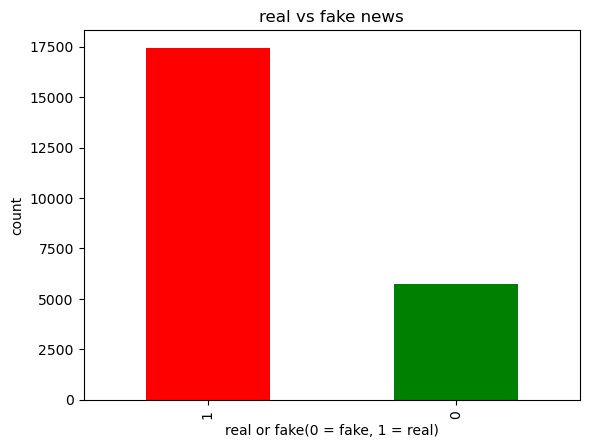

In [ ]:
df["real"].value_counts().plot(
    kind="bar", title="real vs fake news", color=["red", "green"]
)
plt.xlabel("real or fake(0 = fake, 1 = real)")
plt.ylabel("count")

In [ ]:
(df["real"] == 1).sum()

17441

In [ ]:
(df["real"] == 0).sum()

5755

In [ ]:
print(df.dtypes)  # Shows data types of all columns

title    object
real      int64
dtype: object


In [ ]:
x = df["title"]
y = df["real"]

In [17]:
x_train, x_valid, x_test = np.split(
    x.sample(frac=1), [int(0.6 * len(x)), int(0.8 * len(x))]
)

c:\Users\HP\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


In [18]:
y_train, y_valid, y_test = np.split(
    y.sample(frac=1), [int(0.6 * len(y)), int(0.8 * len(y))]
)

In [ ]:
def vectorisation(train, valid, test):
    vectorization = TfidfVectorizer()
    xv_train = vectorization.fit_transform(x_train)
    xv_valid = vectorization.transform(x_valid)
    xv_test = vectorization.transform(x_test)
    return xv_train, xv_valid, xv_test

In [20]:
xv_train, xv_valid, xv_test = vectorisation(x_train, x_valid, x_test)

In [ ]:
print("Min:", np.min(xv_train))
print("Max:", np.max(xv_train))

Min: 0.0
Max: 1.0


In [22]:
xv_train

<13917x15265 sparse matrix of type '<class 'numpy.float64'>'
	with 146184 stored elements in Compressed Sparse Row format>

In [23]:
xv_test

<4640x15265 sparse matrix of type '<class 'numpy.float64'>'
	with 46492 stored elements in Compressed Sparse Row format>

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_balanced, y_train_balanced = smote.fit_resample(xv_train, y_train)

# SVM


In [27]:
from sklearn.svm import SVC

In [28]:
svc_model = SVC()
svc_model.fit(x_train_balanced, y_train_balanced)

SVC()

In [29]:
y_pred = svc_model.predict(xv_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.22      0.02      0.03      1133
           1       0.76      0.98      0.85      3507

    accuracy                           0.75      4640
   macro avg       0.49      0.50      0.44      4640
weighted avg       0.63      0.75      0.65      4640



# KNN


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()
knn.fit(xv_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(xv_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.21      0.09      0.13       560
         1.0       0.75      0.88      0.81      1700

    accuracy                           0.69      2260
   macro avg       0.48      0.49      0.47      2260
weighted avg       0.61      0.69      0.64      2260



# Log Regrassion


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
log_model = LogisticRegression()
log_model.fit(xv_train, y_train)

LogisticRegression()

In [ ]:
y_pred = log_model.predict(xv_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       560
         1.0       0.75      1.00      0.86      1700

    accuracy                           0.75      2260
   macro avg       0.38      0.50      0.43      2260
weighted avg       0.57      0.75      0.65      2260

